### The University of Melbourne, School of Computing and Information Systems
# COMP90086 Computer Vision, 2025 Semester 2

## FINAL PROJECT

In [1]:
import tensorflow as tf
import pandas as pd
import os
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# --- Configuration ---
IMG_HEIGHT = 320
IMG_WIDTH = 240
BATCH_SIZE = 16
BASE_DIR = "Nutrition5k"
VALIDATION_SPLIT = 0.20 # 20% for validation
RANDOM_SEED = 42 # Use a seed for reproducible splits

# --- 1. Load the full labeled dataset manifest ---
full_labels_path = os.path.join(BASE_DIR, "nutrition5k_train.csv")
df = pd.read_csv(full_labels_path)
df['ID'] = df['ID'].astype(str)

print(f"DataFrame size before cleaning: {len(df)}")
df = df[df['ID'] != 'dish_2368']
print(f"DataFrame size after removing dish_2368: {len(df)}")




DataFrame size before cleaning: 3301
DataFrame size after removing dish_2368: 3300


## loading test data

In [2]:
# complete train and test split (with normalised pixel values)
df = df.assign(train_image_path=BASE_DIR + "\\train\\color\\" + df["ID"].astype(str) + "\\rgb.png",
               test_image_path=BASE_DIR + "\\test\\color\\" + df["ID"].astype(str) + "\\rgb.png")

datagen = ImageDataGenerator(rescale=1./255,
                             validation_split=VALIDATION_SPLIT)

train_generator = datagen.flow_from_dataframe(
        dataframe=df,
        directory=os.getcwd(), # Root directory where image folders are located
        x_col='train_image_path', # Column in DataFrame containing image paths
        y_col='Value', # Column in DataFrame containing labels
        target_size=(IMG_HEIGHT, IMG_WIDTH), # Resize images to this size
        batch_size=BATCH_SIZE,
        class_mode='raw', # Or 'binary', 'sparse', 'input', None
        seed=RANDOM_SEED,
        subset='training' # For training data
    )


validation_generator = datagen.flow_from_dataframe(
        dataframe=df,
        directory=os.getcwd(), # Root directory where image folders are located
        x_col='train_image_path', # Column in DataFrame containing image paths
        y_col='Value', # Column in DataFrame containing labels
        target_size=(IMG_HEIGHT, IMG_WIDTH), # Resize images to this size
        batch_size=BATCH_SIZE,
        class_mode='raw', # Or 'binary', 'sparse', 'input', None
        seed=RANDOM_SEED,
        subset='validation' # For training data
    )

Found 2640 validated image filenames.
Found 660 validated image filenames.


In [3]:
os.listdir(os.path.join(BASE_DIR, "test/color"))

['dish_3301',
 'dish_3302',
 'dish_3303',
 'dish_3304',
 'dish_3305',
 'dish_3306',
 'dish_3307',
 'dish_3308',
 'dish_3309',
 'dish_3310',
 'dish_3311',
 'dish_3312',
 'dish_3313',
 'dish_3314',
 'dish_3315',
 'dish_3316',
 'dish_3317',
 'dish_3318',
 'dish_3319',
 'dish_3320',
 'dish_3321',
 'dish_3322',
 'dish_3323',
 'dish_3324',
 'dish_3325',
 'dish_3326',
 'dish_3327',
 'dish_3328',
 'dish_3329',
 'dish_3330',
 'dish_3331',
 'dish_3332',
 'dish_3333',
 'dish_3334',
 'dish_3335',
 'dish_3336',
 'dish_3337',
 'dish_3338',
 'dish_3339',
 'dish_3340',
 'dish_3341',
 'dish_3342',
 'dish_3343',
 'dish_3344',
 'dish_3345',
 'dish_3346',
 'dish_3347',
 'dish_3348',
 'dish_3349',
 'dish_3350',
 'dish_3351',
 'dish_3352',
 'dish_3353',
 'dish_3354',
 'dish_3355',
 'dish_3356',
 'dish_3357',
 'dish_3358',
 'dish_3359',
 'dish_3360',
 'dish_3361',
 'dish_3362',
 'dish_3363',
 'dish_3364',
 'dish_3365',
 'dish_3366',
 'dish_3367',
 'dish_3368',
 'dish_3369',
 'dish_3370',
 'dish_3371',
 'dish

In [4]:
# create dataset to load test dataset
df_test = pd.DataFrame({"ID": os.listdir(os.path.join(BASE_DIR, "test/color"))})
df_test = df_test.assign(test_image_path = BASE_DIR + "\\test\\color\\" + df_test["ID"].astype(str) + "\\rgb.png")

In [5]:
df_test

,ID,test_image_path
0,dish_3301,Nutrition5k\test\color\dish_3301\rgb.png
1,dish_3302,Nutrition5k\test\color\dish_3302\rgb.png
2,dish_3303,Nutrition5k\test\color\dish_3303\rgb.png
3,dish_3304,Nutrition5k\test\color\dish_3304\rgb.png
4,dish_3305,Nutrition5k\test\color\dish_3305\rgb.png
...,...,...
184,dish_3485,Nutrition5k\test\color\dish_3485\rgb.png
185,dish_3486,Nutrition5k\test\color\dish_3486\rgb.png
186,dish_3487,Nutrition5k\test\color\dish_3487\rgb.png
187,dish_3488,Nutrition5k\test\color\dish_3488\rgb.png


In [6]:
test_datagen=ImageDataGenerator(rescale=1./255.)
test_generator=test_datagen.flow_from_dataframe(
dataframe=df_test,
directory=os.getcwd(),
x_col="test_image_path",
y_col=None,
target_size=(IMG_HEIGHT, IMG_WIDTH), # Resize images to this size
batch_size=BATCH_SIZE,
seed=RANDOM_SEED,
shuffle=False,
class_mode=None)

Found 189 validated image filenames.


## Multi-Branch Model 

In [7]:
# Add the path for the RGB image (as you already have)
df['rgb_path'] = df.apply(lambda row: os.path.join(BASE_DIR, 'train', 'color', str(row['ID']), 'rgb.png'), axis=1)

# ADD THIS: Add the path for the raw depth image
df['depth_path'] = df.apply(lambda row: os.path.join(BASE_DIR, 'train', 'depth_raw', str(row['ID']), 'depth_raw.png'), axis=1)

In [8]:
import cv2
import numpy as np

def custom_data_generator_multi_branch(dataframe, batch_size, target_size=(128, 128)):
    df = dataframe.copy()
    img_height, img_width = target_size
    
    while True:
        df = df.sample(frac=1) 
        
        for i in range(0, len(df), batch_size):
            batch_df = df.iloc[i : i + batch_size]
            
            # --- MODIFICATION 1: Create two lists for the two branches ---
            batch_rgb_images = []
            batch_depth_images = []
            batch_labels = []

            for index, row in batch_df.iterrows():
                # Load RGB and Depth images
                rgb_img = cv2.imread(row['rgb_path'])
                depth_img = cv2.imread(row['depth_path'], cv2.IMREAD_GRAYSCALE)

                # Check if either image failed to load
                if rgb_img is None:
                    print(f"Error: Could not load RGB image at path: {row['rgb_path']}")
                    continue 
                if depth_img is None:
                    print(f"Error: Could not load depth image at path: {row['depth_path']}")
                    continue

                # Process RGB image
                rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
                rgb_resized = cv2.resize(rgb_img, (img_width, img_height)) / 255.0
                
                # Process Depth image
                depth_resized = cv2.resize(depth_img, (img_width, img_height)) / 255.0
                # Add the channel dimension to make it (H, W, 1)
                depth_with_channel = np.expand_dims(depth_resized, axis=-1)
                
                # --- MODIFICATION 2: Append to separate lists ---
                # We no longer stack them together
                batch_rgb_images.append(rgb_resized)
                batch_depth_images.append(depth_with_channel)
                batch_labels.append(row['Value'])

            # Only yield if the batch is not empty
            if len(batch_rgb_images) > 0:
                
                # --- MODIFICATION 3: Yield the data in the format the model expects ---
                # ( (input_1, input_2), labels )
                
                # Convert lists to float32 numpy arrays to save memory
                rgb_array = np.array(batch_rgb_images, dtype=np.float32)
                depth_array = np.array(batch_depth_images, dtype=np.float32)
                labels_array = np.array(batch_labels, dtype=np.float32)

                yield ( (rgb_array, depth_array), labels_array )

In [9]:
from tensorflow.keras import layers, models

# --- Define Model Inputs ---
rgb_input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name='rgb_input')
depth_input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1), name='depth_input')

# --- Branch 1: The RGB Expert ---
rgb_branch = layers.Conv2D(32, (3, 3), activation='relu')(rgb_input)
rgb_branch = layers.MaxPooling2D((2, 2))(rgb_branch)
rgb_branch = layers.Flatten()(rgb_branch)

# --- Branch 2: The Depth Expert ---
depth_branch = layers.Conv2D(16, (3, 3), activation='relu')(depth_input)
depth_branch = layers.MaxPooling2D((2, 2))(depth_branch)
depth_branch = layers.Flatten()(depth_branch)

# --- Combine the "expert opinions" ---
combined = layers.concatenate([rgb_branch, depth_branch])

# --- Add the final prediction head ---
head = layers.Dense(64, activation='relu')(combined)
output = layers.Dense(1, activation='linear')(head) # Regression output

# --- Create the final model ---
model = models.Model(inputs=[rgb_input, depth_input], outputs=output)

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 320, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depth_input         │ (None, 320, 240,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 318, 238,  │        896 │ rgb_input[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 318, 238,  │        160 │ depth_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 159, 119,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 159, 119,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 605472)    │          0 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 302736)    │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 908208)    │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │ 58,125,376 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,126,497 (221.73 MB)

 Trainable params: 58,126,497 (221.73 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
train_df, val_df = train_test_split(
    df, 
    test_size=VALIDATION_SPLIT, # e.g., 0.20
    random_state=RANDOM_SEED    # e.g., 42, for reproducible results
)

train_gen = custom_data_generator_multi_branch(train_df, BATCH_SIZE, target_size=(IMG_HEIGHT, IMG_WIDTH))
val_gen = custom_data_generator_multi_branch(val_df, BATCH_SIZE, target_size=(IMG_HEIGHT, IMG_WIDTH))

# Calculate the steps
STEP_SIZE_TRAIN = len(train_df) // BATCH_SIZE
STEP_SIZE_VALID = len(val_df) // BATCH_SIZE

# Train the model
model.fit(
    train_gen,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=val_gen,
    validation_steps=STEP_SIZE_VALID,
    epochs=20
)

Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 121s 728ms/step - loss: 42921.7812 - val_loss: 29620.5547
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 117s 711ms/step - loss: 31646.8652 - val_loss: 24691.8984
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 116s 705ms/step - loss: 23737.6406 - val_loss: 20174.7676
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 114s 693ms/step - loss: 26035.9434 - val_loss: 18876.3926
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 113s 687ms/step - loss: 33716.8789 - val_loss: 15673.4551
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 110s 667ms/step - loss: 15383.5566 - val_loss: 14820.7783
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 109s 659ms/step - loss: 10844.4512 - val_loss: 12798.6406
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 109s 660ms/step - loss: 6574.5049 - val_loss: 14862.3340
Epoch 9/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 109s 661ms/step - loss: 4745.3496 - val_loss: 16938.2598
Epoch 10/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 110s 665ms/step - loss: 5303.6533 - val_loss: 16337.4072
Epoch 11/20
165/165 ━━

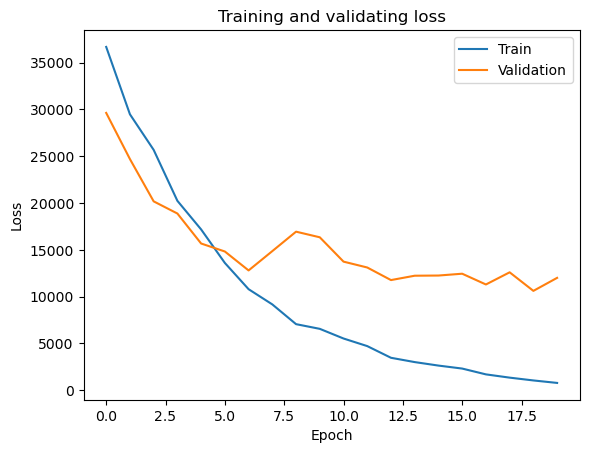

In [11]:
plt.plot(model.history.history['loss'], label='Train')
plt.plot(model.history.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

In [12]:
def custom_test_generator_multi_branch(dataframe, batch_size, target_size=(128, 128)):
    df = dataframe
    img_height, img_width = target_size
    num_samples = len(df)
    
    print(f"--- GENERATOR STARTED ---")
    print(f"Total samples to process: {num_samples}, Batch size: {batch_size}")
    
    yielded_count = 0 # <-- Add counter

    for i in range(0, num_samples, batch_size):
        print(f"\nProcessing batch {i // batch_size + 1}...")
        batch_df = df.iloc[i : i + batch_size]
        
        batch_rgb_images = []
        batch_depth_images = []
        
        processed_in_batch = 0 # <-- Add batch counter

        for index, row in batch_df.iterrows():
            # Load both images
            rgb_img = cv2.imread(row['rgb_path'])
            depth_img = cv2.imread(row['depth_path'], cv2.IMREAD_GRAYSCALE)

            if rgb_img is None or depth_img is None:
                print(f"!!! WARNING: Skipping problematic test image for ID: {row['ID']}") # <-- This is the line we're watching
                continue

            # ... processing ...
            rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
            rgb_resized = cv2.resize(rgb_img, (img_width, img_height)) / 255.0
            depth_resized = cv2.resize(depth_img, (img_width, img_height)) / 255.0
            depth_with_channel = np.expand_dims(depth_resized, axis=-1)
            
            batch_rgb_images.append(rgb_resized)
            batch_depth_images.append(depth_with_channel)
            processed_in_batch += 1 # <-- Increment counter

        if len(batch_rgb_images) > 0:
            yielded_count += len(batch_rgb_images)
            print(f"Yielding batch with {len(batch_rgb_images)} images. Total yielded: {yielded_count}")
            
            # Yield a 1-element TUPLE containing the dictionary
            yield ({
                'rgb_input': np.array(batch_rgb_images, dtype=np.float32), 
                'depth_input': np.array(batch_depth_images, dtype=np.float32)
            },)
        else:
            print(f"Skipping empty batch.")
            
    print(f"--- GENERATOR FINISHED --- Total yielded: {yielded_count}")

In [13]:
df_test

,ID,test_image_path
0,dish_3301,Nutrition5k\test\color\dish_3301\rgb.png
1,dish_3302,Nutrition5k\test\color\dish_3302\rgb.png
2,dish_3303,Nutrition5k\test\color\dish_3303\rgb.png
3,dish_3304,Nutrition5k\test\color\dish_3304\rgb.png
4,dish_3305,Nutrition5k\test\color\dish_3305\rgb.png
...,...,...
184,dish_3485,Nutrition5k\test\color\dish_3485\rgb.png
185,dish_3486,Nutrition5k\test\color\dish_3486\rgb.png
186,dish_3487,Nutrition5k\test\color\dish_3487\rgb.png
187,dish_3488,Nutrition5k\test\color\dish_3488\rgb.png


In [14]:
# Add the path for the RGB image (as you already have)
df_test['rgb_path'] = df_test.apply(lambda row: os.path.join(BASE_DIR, 'test', 'color', str(row['ID']), 'rgb.png'), axis=1)

# ADD THIS: Add the path for the raw depth image
df_test['depth_path'] = df_test.apply(lambda row: os.path.join(BASE_DIR, 'test', 'depth_raw', str(row['ID']), 'depth_raw.png'), axis=1)

In [15]:
df_test

,ID,test_image_path,rgb_path,depth_path
0,dish_3301,Nutrition5k\test\color\dish_3301\rgb.png,Nutrition5k\test\color\dish_3301\rgb.png,Nutrition5k\test\depth_raw\dish_3301\depth_raw...
1,dish_3302,Nutrition5k\test\color\dish_3302\rgb.png,Nutrition5k\test\color\dish_3302\rgb.png,Nutrition5k\test\depth_raw\dish_3302\depth_raw...
2,dish_3303,Nutrition5k\test\color\dish_3303\rgb.png,Nutrition5k\test\color\dish_3303\rgb.png,Nutrition5k\test\depth_raw\dish_3303\depth_raw...
3,dish_3304,Nutrition5k\test\color\dish_3304\rgb.png,Nutrition5k\test\color\dish_3304\rgb.png,Nutrition5k\test\depth_raw\dish_3304\depth_raw...
4,dish_3305,Nutrition5k\test\color\dish_3305\rgb.png,Nutrition5k\test\color\dish_3305\rgb.png,Nutrition5k\test\depth_raw\dish_3305\depth_raw...
...,...,...,...,...
184,dish_3485,Nutrition5k\test\color\dish_3485\rgb.png,Nutrition5k\test\color\dish_3485\rgb.png,Nutrition5k\test\depth_raw\dish_3485\depth_raw...
185,dish_3486,Nutrition5k\test\color\dish_3486\rgb.png,Nutrition5k\test\color\dish_3486\rgb.png,Nutrition5k\test\depth_raw\dish_3486\depth_raw...
186,dish_3487,Nutrition5k\test\color\dish_3487\rgb.png,Nutrition5k\test\color\dish_3487\rgb.png,Nutrition5k\test\depth_raw\dish_3487\depth_raw...
187,dish_3488,Nutrition5k\test\color\dish_3488\rgb.png,Nutrition5k\test\color\dish_3488\rgb.png,Nutrition5k\test\depth_raw\dish_3488\depth_raw...


In [16]:
import cv2
import pandas as pd

# 1. Make sure you have your df_test from the previous step
# (It should have the 'ID', 'rgb_path', and 'depth_path' columns)
# print(df_test.head())

# 2. Define the helper function to check images
def are_paths_valid(row):
    # Try to read both images
    rgb_img = cv2.imread(row['rgb_path'])
    depth_img = cv2.imread(row['depth_path'], cv2.IMREAD_GRAYSCALE)
    
    # Return True if BOTH images loaded successfully, False otherwise
    return (rgb_img is not None) and (depth_img is not None)

# 3. Apply this function to every row. This will take a moment.
print("Finding problematic images...")
valid_mask = df_test.apply(are_paths_valid, axis=1)
print("Check complete.")

# 4. To find the *failed* images, just invert the mask (using ~)
# This selects all rows where are_paths_valid returned False
df_failed = df_test[~valid_mask]

# 5. Now, just get the list of 'ID's from that new dataframe
failed_ids_list = df_failed['ID'].tolist()

if len(failed_ids_list) > 0:
    print(f"\nA total of {len(failed_ids_list)} images failed to load.")
    print("Their IDs are:")
    print(failed_ids_list)
else:
    print("\nGood news! All 189 images loaded correctly.")
    print("If you still have a mismatch, the error may be somewhere else.")

# You can also inspect the full paths of the failed images
# print("\nFull details on failed images:")
# print(df_failed)



Finding problematic images...
Check complete.

Good news! All 189 images loaded correctly.
If you still have a mismatch, the error may be somewhere else.


In [17]:
import os
import math

# 1. Define test directory
test_dir = os.path.join(BASE_DIR, "test")

# 2. Get test IDs
test_ids = os.listdir(os.path.join(test_dir, "color"))
df_test = pd.DataFrame({"ID": test_ids})

# 3. Create BOTH paths correctly
df_test['rgb_path'] = df_test.apply(lambda row: os.path.join(test_dir, 'color', str(row['ID']), 'rgb.png'), axis=1)
df_test['depth_path'] = df_test.apply(lambda row: os.path.join(test_dir, 'depth_raw', str(row['ID']), 'depth_raw.png'), axis=1)

print("Creating test generator...")
test_gen = custom_test_generator_multi_branch(
    df_test, 
    BATCH_SIZE, 
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

# 5. Calculate steps
TEST_STEPS = math.ceil(len(df_test) / BATCH_SIZE)

# --- ADD THESE DEBUG PRINTS ---
print("\n--- PREDICTION DEBUG ---")
print(f"len(df_test): {len(df_test)}")
print(f"BATCH_SIZE: {BATCH_SIZE}") # Make sure this is the number you expect!
print(f"TEST_STEPS calculated: {TEST_STEPS}")
print("--------------------------\n")
print("Calling model.predict()...")

# 6. Get predictions
predictions = model.predict(test_gen, steps=TEST_STEPS)

print("...model.predict() finished.")
print(f"Length of predictions received: {len(predictions)}")

Creating test generator...

--- PREDICTION DEBUG ---
len(df_test): 189
BATCH_SIZE: 16
TEST_STEPS calculated: 12
--------------------------

Calling model.predict()...
--- GENERATOR STARTED ---
Total samples to process: 189, Batch size: 16

Processing batch 1...
Yielding batch with 16 images. Total yielded: 16

Processing batch 2...
Yielding batch with 16 images. Total yielded: 32
 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step
Processing batch 3...
 2/12 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/stepYielding batch with 16 images. Total yielded: 48

Processing batch 4...
 3/12 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/stepYielding batch with 16 images. Total yielded: 64

Processing batch 5...
 4/12 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/stepYielding batch with 16 images. Total yielded: 80

Processing batch 6...
 5/12 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/stepYielding batch with 16 images. Total yielded: 96

Processing batch 7...
 6/12 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/stepYielding batch with 16 images. Total yielded: 112

Processing batc

In [18]:
# Add the predictions as a new column
df_test = df_test.assign(Value=predictions)

# Create the submission DataFrame by dropping the path columns
# This is the line to fix:
df_submit = df_test.drop(["depth_path", "rgb_path"], axis=1)

# A slightly more modern (and readable) way to do the same thing:
# df_submit = df_test.drop(columns=["depth_path", "rgb_path"])

# Check your final DataFrame
df_submit.to_csv("multi_branch_submission_1.csv", index = False)

## improvement_1 channel stacking on using the depth image

In [19]:
# Add the path for the RGB image (as you already have)
df['rgb_path'] = df.apply(lambda row: os.path.join(BASE_DIR, 'train', 'color', str(row['ID']), 'rgb.png'), axis=1)

# ADD THIS: Add the path for the raw depth image
df['depth_path'] = df.apply(lambda row: os.path.join(BASE_DIR, 'train', 'depth_raw', str(row['ID']), 'depth_raw.png'), axis=1)

# Now your DataFrame has columns for both image paths
print(df.head())

          ID       Value                           train_image_path  \
0  dish_0000  221.167068  Nutrition5k\train\color\dish_0000\rgb.png   
1  dish_0001  140.980011  Nutrition5k\train\color\dish_0001\rgb.png   
2  dish_0002  274.335999  Nutrition5k\train\color\dish_0002\rgb.png   
3  dish_0003  589.501648  Nutrition5k\train\color\dish_0003\rgb.png   
4  dish_0004  258.599670  Nutrition5k\train\color\dish_0004\rgb.png   

                            test_image_path  \
0  Nutrition5k\test\color\dish_0000\rgb.png   
1  Nutrition5k\test\color\dish_0001\rgb.png   
2  Nutrition5k\test\color\dish_0002\rgb.png   
3  Nutrition5k\test\color\dish_0003\rgb.png   
4  Nutrition5k\test\color\dish_0004\rgb.png   

                                    rgb_path  \
0  Nutrition5k\train\color\dish_0000\rgb.png   
1  Nutrition5k\train\color\dish_0001\rgb.png   
2  Nutrition5k\train\color\dish_0002\rgb.png   
3  Nutrition5k\train\color\dish_0003\rgb.png   
4  Nutrition5k\train\color\dish_0004\rgb.png   

 

In [20]:
import cv2
import numpy as np

def custom_data_generator(dataframe, batch_size, target_size=(128, 128)):
    df = dataframe.copy()
    img_height, img_width = target_size
    
    while True:
        df = df.sample(frac=1) 
        
        for i in range(0, len(df), batch_size):
            batch_df = df.iloc[i : i + batch_size]
            
            batch_images = []
            batch_labels = []

            for index, row in batch_df.iterrows():
                # Load RGB and Depth images
                rgb_img = cv2.imread(row['rgb_path'])
                depth_img = cv2.imread(row['depth_path'], cv2.IMREAD_GRAYSCALE)

                # --- ADD THIS CHECK ---
                # Check if either image failed to load
                if rgb_img is None:
                    print(f"Error: Could not load RGB image at path: {row['rgb_path']}")
                    continue # Skip this problematic image
                
                if depth_img is None:
                    print(f"Error: Could not load depth image at path: {row['depth_path']}")
                    continue # Skip this problematic image
                # --- END OF CHECK ---

                # Now it's safe to process the images
                rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
                rgb_resized = cv2.resize(rgb_img, (img_width, img_height)) / 255.0
                depth_resized = cv2.resize(depth_img, (img_width, img_height)) / 255.0
                
                depth_with_channel = np.expand_dims(depth_resized, axis=-1)
                stacked_image = np.concatenate([rgb_resized, depth_with_channel], axis=-1)
                
                batch_images.append(stacked_image)
                batch_labels.append(row['Value'])

            yield (np.array(batch_images), np.array(batch_labels))

In [21]:
train_df, val_df = train_test_split(
    df, 
    test_size=VALIDATION_SPLIT, # e.g., 0.20
    random_state=RANDOM_SEED    # e.g., 42, for reproducible results
)


train_gen = custom_data_generator(train_df, BATCH_SIZE, target_size=(IMG_HEIGHT, IMG_WIDTH))
val_gen = custom_data_generator(val_df, BATCH_SIZE, target_size=(IMG_HEIGHT, IMG_WIDTH))

In [22]:
stack_channel_model = tf.keras.Sequential(
    [
        layers.Input((IMG_HEIGHT, IMG_WIDTH, 4)),
        
        layers.Conv2D(8, (5, 5), activation='relu'), # fill in
        layers.MaxPooling2D((2, 2)), # fill in
        
        layers.Flatten(),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="linear")
    ], 
)

stack_channel_model.compile(optimizer='adam', loss='mse', metrics=['mse'])
stack_channel_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 316, 236, 8)    │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 158, 118, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 149152)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │     1,491,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,492,349 (5.69 MB)

 Trainable params: 1,492,349 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
STEP_SIZE_TRAIN = len(train_df) // BATCH_SIZE
STEP_SIZE_VALID = len(val_df) // BATCH_SIZE

stack_channel_model.fit(train_gen,
          steps_per_epoch=STEP_SIZE_TRAIN,
          validation_data=val_gen,
          validation_steps=STEP_SIZE_VALID,
          epochs=20
)


Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 48s 289ms/step - loss: 53765.3242 - mse: 53765.3242 - val_loss: 27686.2930 - val_mse: 27686.2930
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 46s 283ms/step - loss: 49783.7188 - mse: 49783.7188 - val_loss: 24355.7246 - val_mse: 24355.7246
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 46s 281ms/step - loss: 27256.3262 - mse: 27256.3262 - val_loss: 28542.5723 - val_mse: 28542.5723
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 47s 285ms/step - loss: 32608.5254 - mse: 32608.5254 - val_loss: 24465.6621 - val_mse: 24465.6621
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 46s 283ms/step - loss: 24198.7441 - mse: 24198.7441 - val_loss: 23614.5859 - val_mse: 23614.5859
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 43s 263ms/step - loss: 25168.2695 - mse: 25168.2695 - val_loss: 23176.7031 - val_mse: 23176.7031
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 43s 264ms/step - loss: 23202.5020 - mse: 23202.5020 - val_loss: 22977.6230 - val_mse: 22977.6230
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 4

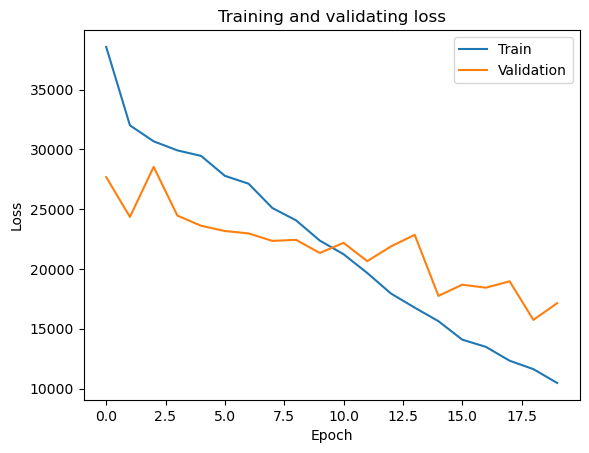

In [24]:
plt.plot(stack_channel_model.history.history['loss'], label='Train')
plt.plot(stack_channel_model.history.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

In [25]:
import cv2
import numpy as np

def custom_test_generator_4_channel(dataframe, batch_size, target_size=(128, 128)):
    df = dataframe
    img_height, img_width = target_size
    num_samples = len(df)
    
    # Loop through the dataframe in batches, in order
    for i in range(0, num_samples, batch_size):
        batch_df = df.iloc[i : i + batch_size]
        
        batch_images = []

        for index, row in batch_df.iterrows():
            # Load both images
            rgb_img = cv2.imread(row['rgb_path'])
            depth_img = cv2.imread(row['depth_path'], cv2.IMREAD_GRAYSCALE)

            # Add error checking here if you want
            if rgb_img is None or depth_img is None:
                print(f"Warning: Skipping problematic test image for ID: {row['ID']}")
                continue
            
            # Process and STACK
            rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
            rgb_resized = cv2.resize(rgb_img, (img_width, img_height)) / 255.0
            depth_resized = cv2.resize(depth_img, (img_width, img_height)) / 255.0
            depth_with_channel = np.expand_dims(depth_resized, axis=-1)
            stacked_image = np.concatenate([rgb_resized, depth_with_channel], axis=-1)
            
            batch_images.append(stacked_image)

        if len(batch_images) > 0:
            # Yield a 1-element TUPLE containing the batch
            yield (np.array(batch_images, dtype=np.float32),) # <-- Add comma here

In [26]:
import os
import math

# 1. Define test directory
test_dir = os.path.join(BASE_DIR, "test")

# 2. Get test IDs
test_ids = os.listdir(os.path.join(test_dir, "color"))
df_test = pd.DataFrame({"ID": test_ids})

# 3. Create BOTH paths correctly
df_test['rgb_path'] = df_test.apply(lambda row: os.path.join(test_dir, 'color', str(row['ID']), 'rgb.png'), axis=1)
df_test['depth_path'] = df_test.apply(lambda row: os.path.join(test_dir, 'depth_raw', str(row['ID']), 'depth_raw.png'), axis=1)

# 4. Create ONE of the generators
test_gen = custom_test_generator_4_channel(
    df_test, 
    BATCH_SIZE, 
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)
# OR
# test_gen = custom_test_generator_4_channel(...)

# 5. Calculate steps
TEST_STEPS = math.ceil(len(df_test) / BATCH_SIZE)

# 6. Get predictions
predictions = stack_channel_model.predict(test_gen, steps=TEST_STEPS)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step


In [27]:
# Add the predictions as a new column
df_test = df_test.assign(Value=predictions)

# Create the submission DataFrame by dropping the path columns
# This is the line to fix:
df_submit = df_test.drop(["depth_path", "rgb_path"], axis=1)

# A slightly more modern (and readable) way to do the same thing:
# df_submit = df_test.drop(columns=["depth_path", "rgb_path"])

# Check your final DataFrame
df_submit.to_csv("stack_channel_submission_1.csv", index = False)

## Build and Train a conventional baseline classfier


In [28]:
# build basic regression model
baseline_model = tf.keras.Sequential(
    [
        layers.Input((IMG_HEIGHT, IMG_WIDTH, 3)),
        
        layers.Conv2D(8, (5, 5), activation='relu'), # fill in
        layers.MaxPooling2D((2, 2)), # fill in
        
        layers.Flatten(),
        layers.Dense(10, activation="relu"),
        layers.Dense(1, activation="linear")
    ], 
)

baseline_model.compile(optimizer='adam', loss='mse', metrics=['mse'])
baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 316, 236, 8)    │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 158, 118, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 149152)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │     1,491,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,492,149 (5.69 MB)

 Trainable params: 1,492,149 (5.69 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = validation_generator.n//validation_generator.batch_size

baseline_model.fit(train_generator,
          steps_per_epoch=STEP_SIZE_TRAIN,
          validation_data=validation_generator,
          validation_steps=STEP_SIZE_VALID,
          epochs=20
)


c:\Users\nares\anaconda3\envs\CV\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 32s 189ms/step - loss: 37834.6914 - mse: 37834.6914 - val_loss: 32098.6738 - val_mse: 32098.6738
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - loss: 27949.4688 - mse: 27949.4688 - val_loss: 23962.9570 - val_mse: 23962.9570
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 30s 183ms/step - loss: 37795.7891 - mse: 37795.7891 - val_loss: 24838.7871 - val_mse: 24838.7871
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - loss: 22872.0566 - mse: 22872.0566 - val_loss: 23286.6680 - val_mse: 23286.6680
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - loss: 23616.4258 - mse: 23616.4258 - val_loss: 22331.3535 - val_mse: 22331.3535
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - loss: 22467.0664 - mse: 22467.0664 - val_loss: 20129.0254 - val_mse: 20129.0254
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 30s 181ms/step - loss: 30083.4883 - mse: 30083.4883 - val_loss: 26482.3477 - val_mse: 26482.3477
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 3

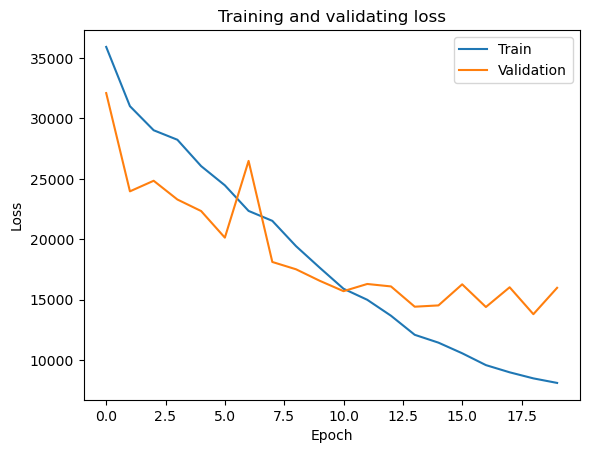

In [30]:
plt.plot(baseline_model.history.history['loss'], label='Train')
plt.plot(baseline_model.history.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

In [31]:
# validation
STEP_SIZE_TEST=test_generator.n//test_generator.batch_size
baseline_model.evaluate(validation_generator)

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - loss: 16024.4746 - mse: 16024.4746


[15918.498046875, 15918.498046875]

In [32]:
test_generator.reset()
preds=baseline_model.predict(test_generator)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step


In [33]:
df_test = df_test.assign(Value=preds)

In [34]:
df_test

,ID,rgb_path,depth_path,Value
0,dish_3301,Nutrition5k\test\color\dish_3301\rgb.png,Nutrition5k\test\depth_raw\dish_3301\depth_raw...,832.079651
1,dish_3302,Nutrition5k\test\color\dish_3302\rgb.png,Nutrition5k\test\depth_raw\dish_3302\depth_raw...,0.138982
2,dish_3303,Nutrition5k\test\color\dish_3303\rgb.png,Nutrition5k\test\depth_raw\dish_3303\depth_raw...,65.145691
3,dish_3304,Nutrition5k\test\color\dish_3304\rgb.png,Nutrition5k\test\depth_raw\dish_3304\depth_raw...,96.268654
4,dish_3305,Nutrition5k\test\color\dish_3305\rgb.png,Nutrition5k\test\depth_raw\dish_3305\depth_raw...,286.749969
...,...,...,...,...
184,dish_3485,Nutrition5k\test\color\dish_3485\rgb.png,Nutrition5k\test\depth_raw\dish_3485\depth_raw...,85.236313
185,dish_3486,Nutrition5k\test\color\dish_3486\rgb.png,Nutrition5k\test\depth_raw\dish_3486\depth_raw...,0.123467
186,dish_3487,Nutrition5k\test\color\dish_3487\rgb.png,Nutrition5k\test\depth_raw\dish_3487\depth_raw...,258.926483
187,dish_3488,Nutrition5k\test\color\dish_3488\rgb.png,Nutrition5k\test\depth_raw\dish_3488\depth_raw...,107.302528


In [35]:
df_test

,ID,rgb_path,depth_path,Value
0,dish_3301,Nutrition5k\test\color\dish_3301\rgb.png,Nutrition5k\test\depth_raw\dish_3301\depth_raw...,832.079651
1,dish_3302,Nutrition5k\test\color\dish_3302\rgb.png,Nutrition5k\test\depth_raw\dish_3302\depth_raw...,0.138982
2,dish_3303,Nutrition5k\test\color\dish_3303\rgb.png,Nutrition5k\test\depth_raw\dish_3303\depth_raw...,65.145691
3,dish_3304,Nutrition5k\test\color\dish_3304\rgb.png,Nutrition5k\test\depth_raw\dish_3304\depth_raw...,96.268654
4,dish_3305,Nutrition5k\test\color\dish_3305\rgb.png,Nutrition5k\test\depth_raw\dish_3305\depth_raw...,286.749969
...,...,...,...,...
184,dish_3485,Nutrition5k\test\color\dish_3485\rgb.png,Nutrition5k\test\depth_raw\dish_3485\depth_raw...,85.236313
185,dish_3486,Nutrition5k\test\color\dish_3486\rgb.png,Nutrition5k\test\depth_raw\dish_3486\depth_raw...,0.123467
186,dish_3487,Nutrition5k\test\color\dish_3487\rgb.png,Nutrition5k\test\depth_raw\dish_3487\depth_raw...,258.926483
187,dish_3488,Nutrition5k\test\color\dish_3488\rgb.png,Nutrition5k\test\depth_raw\dish_3488\depth_raw...,107.302528


In [36]:
df_submit = df_submit = df_test.drop(["depth_path", "rgb_path"], axis=1)

In [37]:
df_submit

,ID,Value
0,dish_3301,832.079651
1,dish_3302,0.138982
2,dish_3303,65.145691
3,dish_3304,96.268654
4,dish_3305,286.749969
...,...,...
184,dish_3485,85.236313
185,dish_3486,0.123467
186,dish_3487,258.926483
187,dish_3488,107.302528


In [38]:
# save copy to csv
df_submit.to_csv("baseline_1.csv")